# PANGA EDA → xarray NetCDF (header-aware)

This notebook:
- Reads PANGA files downloaded from:https://panga.org/pub/data/incoming/panga_nam20_20260117.tar.gz
- combine components
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/panga_nam20_20260117/")  # directory containing *.series

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
print("OK:", DATA_DIR)


OK: data\panga_nam20_20260117


## 2) read panga files

In [3]:
# Year E N V SigmaE SigmaN SigmaV CorrEN CorrEV CorrNV JSec Year Month Day Hour Minute Second
SERIES_COLS = [
    "dec_year",  # the leading "Year" (often decimal year-ish in some formats)
    "east_m",
    "north_m",
    "up_m",
    "east_sigma_m",
    "north_sigma_m",
    "up_sigma_m",
    "corr_en",
    "corr_eu",
    "corr_nu",
    "jsec",
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "second",
]

# Some files label "V" (vertical) but you want "up" — we map to up_m above.


def _find_series_data_start_line(path: Path) -> int:
    """
    Return 0-based line index where numeric data begins.

    We scan for a header line containing the key tokens, then return next line.
    If no header is found, we assume data starts at the first non-comment line.
    """
    header_pat = re.compile(r"\bYear\b.*\bE\b.*\bN\b.*\bV\b", flags=re.IGNORECASE)

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for i, raw in enumerate(f):
            line = raw.strip()
            if not line:
                continue
            if line.startswith("#"):
                # Header might be commented; still detect it.
                if header_pat.search(line.lstrip("#").strip()):
                    return i + 1
                continue
            # Non-comment line: could be header or data.
            if header_pat.search(line):
                return i + 1
            # If it looks numeric, treat as start of data
            if re.match(r"^[\s\-\d\.]+$", line):
                return i

    raise ValueError(f"Could not determine data start line in {path}")


def read_panga_series_file(path: Path) -> pd.DataFrame:
    """
    Read one file like 'ALBH.series' and return a tidy dataframe with:

      station, time, year, doy,
      east_m, north_m, up_m,
      east_sigma_m, north_sigma_m, up_sigma_m,
      corr_en, corr_eu, corr_nu

    Time is date-only (00:00 UTC), ignoring hour/min/sec fields.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    station_id = path.stem.split(".")[0].lower()
    start = _find_series_data_start_line(path)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        skiprows=start,
        comment="#",
        header=None,
        names=SERIES_COLS,
    )

    # --- numeric coercion ---
    for c in SERIES_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # --- build date-only datetime (no HMS) ---
    time = pd.to_datetime(
        dict(
            year=df["year"],
            month=df["month"],
            day=df["day"],
        ),
        errors="coerce",
        utc=True,
    )

    df["time"] = time
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

    # If timezone-aware, strip timezone (-> numpy datetime64[ns])
    if getattr(df["time"].dt, "tz", None) is not None:
        df["time"] = df["time"].dt.tz_convert(None)

    # Optional: ensure day-only (midnight)
    df["time"] = df["time"].dt.floor("D")
        
    df["station"] = station_id

    # --- drop bad epochs ---
    df = df.dropna(
        subset=[
            "time",
            "east_m",
            "north_m",
            "up_m",
        ]
    ).reset_index(drop=True)

    return df[
        [
            "station",
            "time",
            "dec_year",
            "east_m",
            "north_m",
            "up_m",
            "east_sigma_m",
            "north_sigma_m",
            "up_sigma_m",
            # "corr_en",
            # "corr_eu",
            # "corr_nu",
        ]
    ]


def read_panga_series_station(base_dir: Path, station_id: str) -> pd.DataFrame:
    """
    Convenience: read 'ALBH.series' from a folder.
    """
    base_dir = Path(base_dir)
    path = base_dir / f"{station_id}.series"
    return read_panga_series_file(path)


## 4) Inspect one station

In [4]:
stat = "ALBH"

raw = read_panga_series_station(DATA_DIR, stat)
raw

,station,time,dec_year,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m
0,albh,1996-01-01,1995.999995,-0.121765,-0.087744,-0.012735,0.001122,0.001617,0.005101
1,albh,1996-01-02,1996.002733,-0.122671,-0.089034,-0.012756,0.001115,0.001617,0.005101
2,albh,1996-01-03,1996.005471,-0.122649,-0.089833,-0.006653,0.001126,0.001614,0.005114
3,albh,1996-01-04,1996.008209,-0.121555,-0.088668,-0.004907,0.001106,0.001596,0.005013
4,albh,1996-01-05,1996.010947,-0.121426,-0.090095,-0.011265,0.001101,0.001586,0.004976
...,...,...,...,...,...,...,...,...,...
10933,albh,2025-12-23,2025.976724,0.068945,0.046942,0.003837,0.000935,0.001353,0.004238
10934,albh,2025-12-24,2025.979461,0.069758,0.048069,0.008573,0.000968,0.001398,0.004440
10935,albh,2025-12-25,2025.982199,0.069569,0.047117,0.003635,0.000967,0.001414,0.004385
10936,albh,2025-12-26,2025.984937,0.068642,0.047204,0.007811,0.000995,0.001463,0.004484


#### verification plot

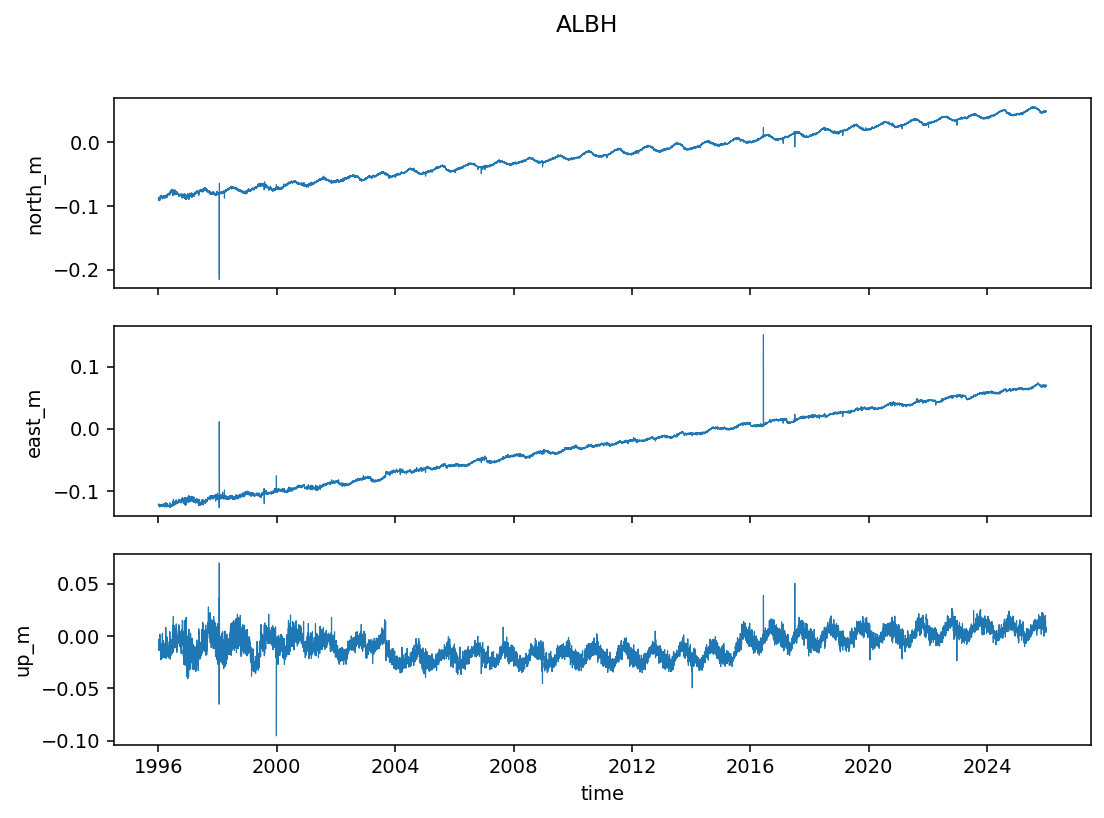

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(raw.time, raw.north_m, lw=0.6)
ax[0].set_ylabel("north_m")

ax[1].plot(raw.time, raw.east_m, lw=0.6)
ax[1].set_ylabel("east_m")

ax[2].plot(raw.time, raw.up_m, lw=0.6)
ax[2].set_ylabel("up_m")
ax[2].set_xlabel("time")

plt.suptitle(stat)
plt.show()


## 5) Apply filters: 2010→present and >5 years

In [6]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [11]:
START_YEAR = 2010.0
END_YEAR = 2025 + 1
MIN_YEARS = 5.0


def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()


def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)


ts_by_station = {}
fail = []  # (station, filename, error)
missing_on_disk = []  # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    p = DATA_DIR / f"{st}.series"  # adjust if .enu etc
    if not p.exists():
        missing_on_disk.append(st)
        continue
    try:
        ts = read_panga_series_station(DATA_DIR, st)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, p.name, f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, p.name, str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")


Valid stations loaded: 372
Missing on disk: 181
Failed (parse/filter/span): 51


In [12]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  abby
  abot
  al2h
  alb4
  aldr
  bcab
  bcbu
  bcch
  bcco
  bccq
  bccr
  bccy
  bcdn
  bcdt
  bcho
  bclg
  bcnn
  bcpm
  bcsc
  bcsk
  bcsq
  bcts
  bcut
  bcvi
  bcvt
  bcws
  blnp
  c046
  ca1r
  cacc
  cach
  cacr
  cacy
  caeu
  cafl
  cafm
  cams
  cawi
  cayk
  cbrv
  ccrt
  cedr
  chco
  chw2
  cmbr
  cme6
  cobi
  copm
  coqu
  cot3

--- Failed (first 20) ---
 agns (agns.series): Span < 5.0y after filtering
 blvu (blvu.series): Span < 5.0y after filtering
 brnb (brnb.series): Span < 5.0y after filtering
 bton (bton.series): Span < 5.0y after filtering
 cami (cami.series): Span < 5.0y after filtering
 chst (chst.series): Span < 5.0y after filtering
 coan (coan.series): Span < 5.0y after filtering
 crbn (crbn.series): Span < 5.0y after filtering
 cshr (cshr.series): Span < 5.0y after filtering
 dea2 (dea2.series): Span < 5.0y after filtering
 dowl (dowl.series): Span < 5.0y after filtering
 dwh1 (dwh1.series): Span < 5.0y after filtering

In [13]:
SIG10_TOL = 1e-6  # exact 10.0 usually, but tolerance costs nothing

def _is_sigma10_row(row: pd.Series, tol: float = SIG10_TOL) -> bool:
    sig = np.array(
        [row.get("east_sigma_m"), row.get("north_sigma_m"), row.get("up_sigma_m")],
        dtype=float,
    )
    return np.all(np.isfinite(sig)) and np.all(np.abs(sig - 10.0) <= tol)

def enforce_unique_time_sigma10_exception(df: pd.DataFrame, station: str) -> pd.DataFrame:
    """
    Policy:
      - If no duplicate 'time': return df sorted by time.
      - If exactly one duplicated day with exactly 2 rows:
          - drop the one row whose sigmas are (10,10,10) and continue
          - else raise
      - If more complicated duplicates: raise
    """
    if "time" not in df.columns:
        raise ValueError(f"{station}: missing 'time' column")

    df = df.sort_values("time").reset_index(drop=True)

    dup_mask = df["time"].duplicated(keep=False)
    if not dup_mask.any():
        return df

    dup_df = df.loc[dup_mask].copy()
    dup_times = dup_df["time"].unique()

    n_dup_times = len(dup_times)
    n_dup_rows = len(dup_df)

    # allow only the simplest case: one duplicate time, two rows
    if not (n_dup_times == 1 and n_dup_rows == 2):
        raise ValueError(
            f"{station}: duplicate 'time' too complex "
            f"(dup_times={n_dup_times}, dup_rows={n_dup_rows})"
        )

    idxs = dup_df.index.to_list()
    r0 = df.loc[idxs[0]]
    r1 = df.loc[idxs[1]]

    r0_bad = _is_sigma10_row(r0)
    r1_bad = _is_sigma10_row(r1)

    if r0_bad ^ r1_bad:
        bad_idx = idxs[0] if r0_bad else idxs[1]
        day = pd.Timestamp(dup_times[0]).strftime("%Y-%m-%d")
        print(f"{station}: dropping sigma==10 row on {day}")
        df = df.drop(index=bad_idx).reset_index(drop=True)

        # hard post-condition
        if df["time"].duplicated().any():
            raise ValueError(f"{station}: still has duplicate 'time' after sigma10 drop")

        return df

    day = pd.Timestamp(dup_times[0]).strftime("%Y-%m-%d")
    raise ValueError(
        f"{station}: duplicated day {day} but sigma10 exception not applicable "
        f"(row0_sigma10={r0_bad}, row1_sigma10={r1_bad})"
    )

## 6) xarray Dataset with dims (time, station) and station coords from catalog


In [14]:
list_ds = []
fail = []

for st, tmp_df in ts_by_station.items():
    try:
        df = tmp_df.copy()

        # enforce your cleanup rule BEFORE indexing
        df = enforce_unique_time_sigma10_exception(df, station=st)

        if "station" in df.columns:
            df = df.drop(columns=["station"])

        # build time index
        # Force datetime64[ns] (tz-naive) for xarray compatibility
        
        df = df.set_index("time").sort_index()

        # convert to xarray and add station dimension
        ds_st = df.to_xarray().expand_dims(station=[st])

        list_ds.append(ds_st)

    except Exception as e:
        fail.append((st, str(e)))

ds = xr.concat(list_ds, dim="station", join="outer").sortby("time")

print(f"Stations concatenated: {ds.sizes['station']}")
print(f"Time steps (union):    {ds.sizes['time']}")
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)

ds

pkwd: dropping sigma==10 row on 2011-04-19
Stations concatenated: 372
Time steps (union):    5840


<xarray.Dataset>
Dimensions:        (time: 5840, station: 372)
Coordinates:
  * time           (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2025-12-27
  * station        (station) object 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
Data variables:
    dec_year       (station, time) float64 2.01e+03 2.01e+03 ... 2.026e+03
    east_m         (station, time) float64 -0.02874 -0.02942 ... 0.04713 0.04745
    north_m        (station, time) float64 -0.02503 -0.02536 ... 0.04299 0.04519
    up_m           (station, time) float64 -0.01479 -0.01999 ... -0.01995
    east_sigma_m   (station, time) float64 0.000983 0.000976 ... 0.000936
    north_sigma_m  (station, time) float64 0.00144 0.001429 ... 0.001343 0.00134
    up_sigma_m     (station, time) float64 0.004523 0.004483 ... 0.004296

In [15]:
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)


## 7) Station coords from catalog (CSV)

In [16]:
station_list["station"] = station_list["name"].astype(str).str.strip().str.lower()
station_list = station_list.set_index("station")

station_list_aligned = station_list.reindex(ds.station.to_numpy())

ds = ds.assign_coords(
    lat=("station", station_list_aligned["lat"].to_numpy(dtype=np.float64)),
    lon=("station", station_list_aligned["lon"].to_numpy(dtype=np.float64)),
    elev_m=("station", station_list_aligned["elev_m"].to_numpy(dtype=np.float64)),
)
ds

<xarray.Dataset>
Dimensions:        (time: 5840, station: 372)
Coordinates:
  * time           (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2025-12-27
  * station        (station) object 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
    lat            (station) float64 48.39 48.17 43.82 ... 45.38 43.63 47.29
    lon            (station) float64 -123.5 -122.1 -121.4 ... -123.3 -122.2
    elev_m         (station) float64 31.77 23.29 1.509e+03 ... 86.49 82.06
Data variables:
    dec_year       (station, time) float64 2.01e+03 2.01e+03 ... 2.026e+03
    east_m         (station, time) float64 -0.02874 -0.02942 ... 0.04713 0.04745
    north_m        (station, time) float64 -0.02503 -0.02536 ... 0.04299 0.04519
    up_m           (station, time) float64 -0.01479 -0.01999 ... -0.01995
    east_sigma_m   (station, time) float64 0.000983 0.000976 ... 0.000936
    north_sigma_m  (station, time) float64 0.00144 0.001429 ... 0.001343 0.00134
    up_sigma_m     (station, time) float64 0.004523 0.004483 ... 0.004296

## 8) Write NetCDF (UNR)

In [17]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_PANGA_2010_2025_5y_NA.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_PANGA_2010_2025_5y_NA.nc


## 9) Smoke test: reopen and plot one station

<xarray.Dataset>
Dimensions:        (time: 5840, station: 372)
Coordinates:
  * time           (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2025-12-27
  * station        (station) object 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
    lat            (station) float64 ...
    lon            (station) float64 ...
    elev_m         (station) float64 ...
Data variables:
    dec_year       (station, time) float64 ...
    east_m         (station, time) float64 ...
    north_m        (station, time) float64 ...
    up_m           (station, time) float64 ...
    east_sigma_m   (station, time) float64 ...
    north_sigma_m  (station, time) float64 ...
    up_sigma_m     (station, time) float64 ...


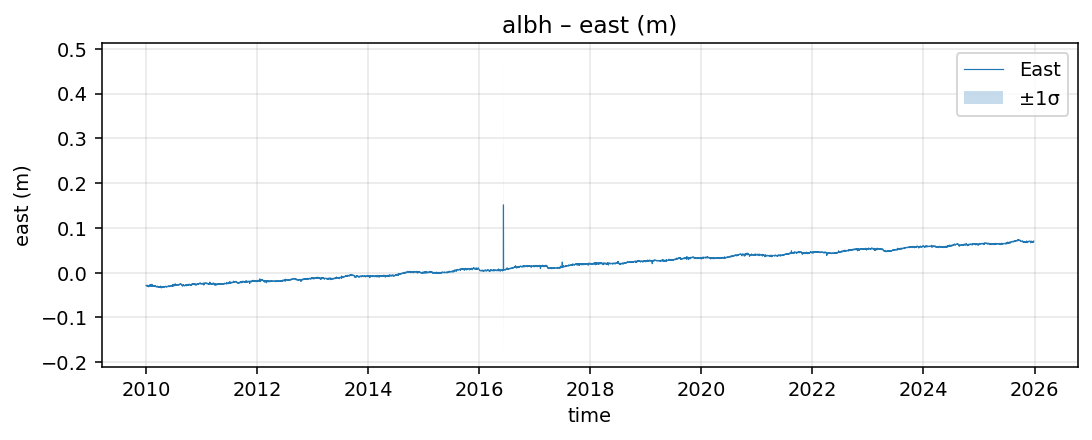

In [18]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "albh"
sel = ds.sel(station=st).dropna(dim="time", how="all")

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


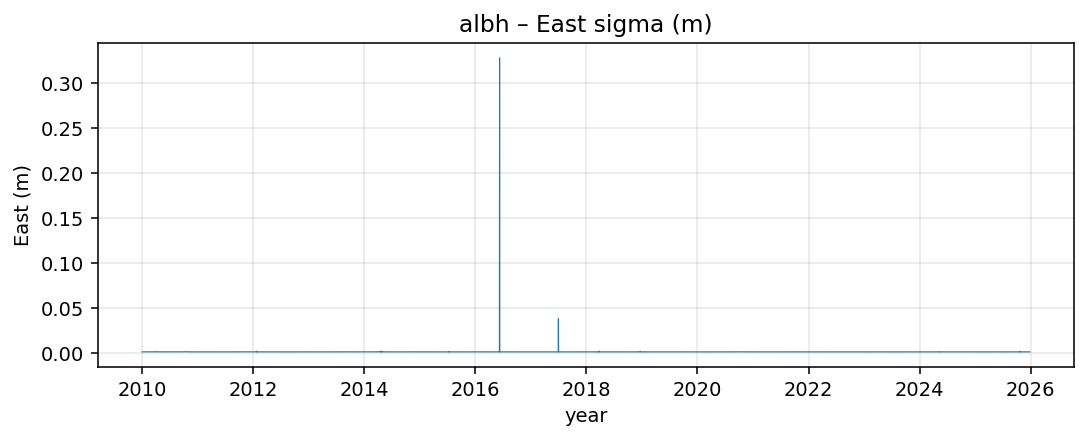

In [19]:
plt.figure(figsize=(9, 3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()

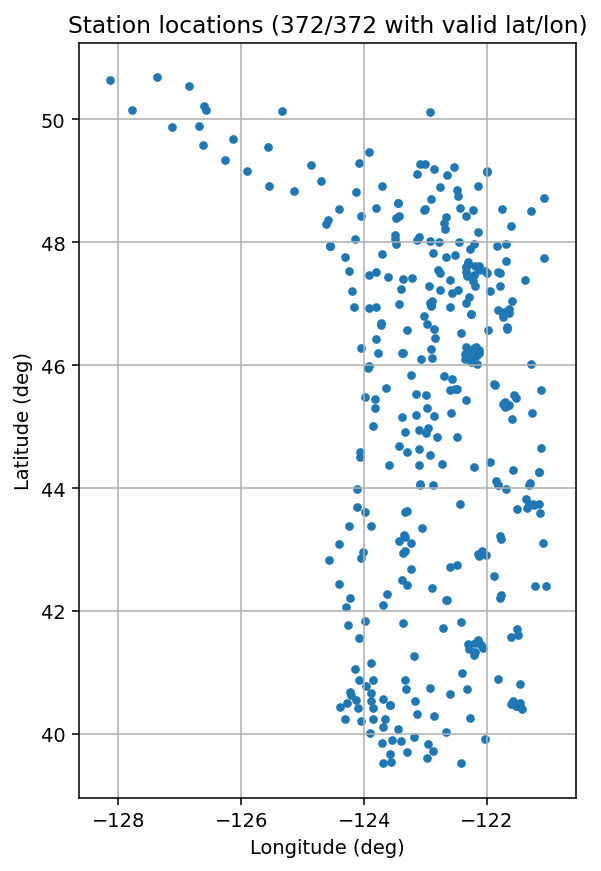

In [20]:
# --- grab station coords ---
lon = ds["lon"].values
lat = ds["lat"].values

mask = np.isfinite(lon) & np.isfinite(lat)
n_total = lon.size
n_ok = int(mask.sum())

# --- plot ---
plt.figure(figsize=(9, 7))
plt.scatter(lon[mask], lat[mask], s=12)  # (no explicit color per your style rule)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

# nice bounds with padding
if n_ok > 0:
    xmin, xmax = np.nanmin(lon[mask]), np.nanmax(lon[mask])
    ymin, ymax = np.nanmin(lat[mask]), np.nanmax(lat[mask])
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    plt.xlim(xmin - pad_x, xmax + pad_x)
    plt.ylim(ymin - pad_y, ymax + pad_y)

plt.show()